# $^{6}\mathrm{Li}$ target thickness estimations for the TRSA experiment at DHIPS

* this notebook estimate the self absorption at given temperatures and 
* the thicknesses of the absorption and scattering targets

## Initialization

In [17]:
import warnings

import os
import sys
import numpy as np
from uncertainties import ufloat
sys.path.append("/home/kprifti/DHIPS2024/TRSA_on_Al27/analysis/ries")
import ries
from scipy.constants import physical_constants
from ries.constituents.element import Element, natural_elements
from ries.constituents.isotope import Isotope
from ries.constituents.state import GroundState, State
#from ries.resonance.voigt import Voigt
from ries.resonance.debye_model import effective_temperature_debye_approximation
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import physical_constants
from scipy.integrate import quad
from scipy.optimize import minimize
from scipy.stats import norm
from time import time


In [18]:
from scipy.optimize import newton
from scipy.stats import cauchy, norm

from ries.resonance.maxwell_boltzmann import MaxwellBoltzmann
from ries.resonance.resonance import Resonance


class PseudoVoigtDistribution:
    """Class for a pseudo-Voigt distribution

    Approximates a Voigt distribution by a linear combination of a normal distribution and a
    Cauchy distribution instead of a convolution.
    For the mixing constant, an expression by Thompson *et al.* :cite:`Thompson1987` is used.

    Attributes:

    - `resonance_energy`, float, resonance energy, i.e. location of the centroid in MeV.
    - `maxwell_boltzmann`, `MaxwellBoltzmann` object, used to calculate the doppler width.
    - `Gamma_L_*`, `Gamma_G_*`, float, parameters used in the approximation of Thompson et al. in units of different powers of MeV.
    - `sigma`, float, standard deviation of the Doppler-broadened normal distribution in MeV.
    - `Gamma`, float, full width at half maximum (FWHM) of the normal distribution in MeV, used in the approximation of Thompson et al..
    - `gamma`, float, scale parameter of the Cauchy distribution.
    - `eta`, float, mixing parameter that controls the relative contributions of the normal- and the Cauchy distribution to the linear combination.
    """

    def __init__(self, resonance_energy, width, amu, effective_temperature):
        """Initialization

        Parameters:

        - `resonance_energy`, float, resonance energy, i.e. location of the centroid in MeV.
        - `width`, float, the width of the excited state in MeV.
        - `amu`, float, mass of the nucleus in atomic mass units.
        - `effective_temperature`, float, effective temperature of the ensemble of nuclei in K.
        """
        self.resonance_energy = resonance_energy
        self.maxwell_boltzmann = MaxwellBoltzmann(amu, effective_temperature)

        self.Gamma_L = width
        self.Gamma_L_squared = self.Gamma_L * self.Gamma_L
        self.Gamma_L_cubed = self.Gamma_L_squared * self.Gamma_L
        self.Gamma_L_squared_squared = self.Gamma_L_squared * self.Gamma_L_squared
        self.doppler_width = self.maxwell_boltzmann.get_doppler_width(
            self.resonance_energy
        )
        self.sigma = self.doppler_width / np.sqrt(2.0)
        self.Gamma_G = 2.0 * np.sqrt(np.log(2.0)) * self.doppler_width
        self.Gamma_G_squared = self.Gamma_G * self.Gamma_G
        self.Gamma_G_squared_squared = self.Gamma_G_squared * self.Gamma_G_squared

        self.Gamma = self.get_Gamma()
        self.eta = self.get_eta()
        self.gamma_G = self.Gamma / (2.0 * np.sqrt(np.log(2.0)))
        self.gamma_L = 0.5 * self.Gamma

        self.gamma = 0.5 * width

    def pseudo_voigt_expression(self, x, method):
        """Evaluate linear combination of normal- and Cauchy distribution

        To avoid repetitive code, this function replaces 'pdf', 'cdf', and 'ppf' in the general
        linear-combination expression.

        Parameters:

        - `x`, float or array_like, meaning depends on the `method` parameter, but it is most probably an energy in MeV (`method == 'pdf'` or `method == 'cdf'`)  or a quantile (`method == ppf`).
        - `method`, str, method of the distributions that should be called, for example 'pdf', 'cdf', or 'ppf'.

        Returns:

        - float or array_like, meaning depends on the `method` parameter, but it is most probably an energy in MeV (`method == 'ppf'`), a probability (`method == pdf`), or a quantile (`method == cdf`).
        """
        return eval(
            """(1.0 - self.eta) * norm.{}(
            x, loc=self.resonance_energy, scale=self.gamma_G / np.sqrt(2.0)
        ) + self.eta * cauchy.{}(
            x, loc=self.resonance_energy, scale=0.5 * self.gamma_L
        )""".format(
                method, method
            )
        )

    def cdf(self, E):
        """CDF of the pseudo-Voigt distribution

        Parameters:

        - `E`, float or array_like, energy in MeV.

        Returns:

        float or array_like, CDF
        """
        return self.pseudo_voigt_expression(E, "cdf")

    def pdf(self, E):
        """PDF of the pseudo-Voigt distribution

        Parameters:

        - `E`, float or array_like, energy in MeV.

        Returns:

        float or array_like, PDF
        """
        return self.pseudo_voigt_expression(E, "pdf")

    def ppf(self, quantile):
        """PPF of the pseudo-Voigt distribution

        This function tries to invert the pseudo-Voigt CDF numerically first.
        If the root-finding algorithm does not converge for any of the given quantiles, the
        RuntimeError issued by the algorithm is caught and a fallback approximation is used which
        is based on a linear combination of PPFs.

        Parameters:

        - `quantile`, float or array_like, quantile.

        Returns:

        float or array_like, PPF
        """

        try:
            # scipy.optimize.newton returns different output depending on whether quantile is a
            # scalar or an array.
            # For a scalar, the root is `newton_result[0]` and the flag that indicates whether
            # the algorithm converged is `newton_result[1]`.converged`.
            # In the case of an array, it is `newton_result[0]` and `newton_result[1]`.
            newton_result = newton(
                lambda E: self.pseudo_voigt_expression(E, "cdf") - quantile,
                # Use resonance energy as start value.
                # There are closer guesses for an arbitrary q, but starting at the resonance
                # energy ensures that the algorithm does not have rounding errors from the start
                # which might cause it to go in the wrong direction.
                self.resonance_energy
                if isinstance(quantile, (float, int))
                else self.resonance_energy * np.ones(len(quantile)),
                fprime=lambda E: self.pseudo_voigt_expression(E, "pdf"),
                full_output=True,
            )
            if isinstance(quantile, (int, float)):
                if newton_result[1].converged:
                    return newton_result[0]
            elif False not in newton_result[1]:
                return newton_result[0]

        except RuntimeError:
            warnings.warn(
                "Calculation of pseudo-Voigt PPF by numerical inversion of the CDF failed for at least one value. Using approximation instead.",
                UserWarning,
            )
            return self.pseudo_voigt_expression(quantile, "ppf")

    def get_Gamma(self):
        """Calculate Gamma parameter

        This parameter is used internally in the approximation of Thompson et al..
        """
        return (
            self.Gamma_G_squared_squared * self.Gamma_G
            + 2.69269 * self.Gamma_G_squared_squared * self.Gamma_L
            + 2.42843 * self.Gamma_G_squared * self.Gamma_G * self.Gamma_L_squared
            + 4.47163 * self.Gamma_G_squared * self.Gamma_L_cubed
            + 0.07842 * self.Gamma_G * self.Gamma_L_squared_squared
            + self.Gamma_L_squared_squared * self.Gamma_L
        ) ** 0.2

    def get_eta(self):
        """Calculate mixing parameter"""
        inverse_Gamma = 1.0 / self.Gamma
        inverse_Gamma_squared = inverse_Gamma * inverse_Gamma
        return (
            1.36603 * self.Gamma_L * inverse_Gamma
            - 0.47719 * self.Gamma_L_squared * inverse_Gamma_squared
            + 0.11116 * self.Gamma_L_cubed * inverse_Gamma_squared * inverse_Gamma
        )


class PseudoVoigt(Resonance):
    r"""Approximation for a Doppler-broadened Breit-Wigner cross section (pseudo-Voigt profile)

    See `ries.resonance.resonance.Resonance`.
    """

    def __init__(
        self,
        initial_state,
        intermediate_state,
        amu,
        effective_temperature,
        final_state=None,
    ):
        r"""Initialization

        Parameters:

        - `amu`, float, mass of the nucleus in atomic mass units.
        - `effective_temperature`, float, effective temperature of the ensemble of nuclei in K.

        See also `ries.resonance.resonance.Resonance`.
        """
        Resonance.__init__(self, initial_state, intermediate_state, final_state)

        self.probability_distribution = PseudoVoigtDistribution(
            self.resonance_energy,
            self.intermediate_state.width,
            amu,
            effective_temperature,
        )
        self.probability_distribution_parameters = ()


In [19]:
from scipy.special import voigt_profile

class SemiPseudoVoigtDistribution(PseudoVoigtDistribution):
    """Class for a Voigt distribution, using pseudo-Voigt expressions for CDF and PPF

    The `pdf()` method calls `scipy.special.voigt_profile`, while the CDF and the PPF are approximated
    by a pseudo-Voigt distribution (see `ries.resonance.pseudo_voigt`).

    See also `ries.resonance.pseudo_voigt.PseudoVoigtDistribution`.
    """

    def pdf(self, E):
        """PDF of Voigt distribution

        Wraps `scipy.special.voigt_profile`.

        Parameter

        - `E`, float or array_like, energy of the incident beam particle in MeV.

        Returns:

        - float or array_like, PDF
        """
        return voigt_profile(E - self.resonance_energy, self.sigma, self.gamma)


class Voigt(PseudoVoigt):
    r"""Class for a Doppler-broadened Breit-Wigner cross section (Voigt profile)

    See `ries.resonance.resonance.Resonance`.
    """

    def __init__(
        self,
        initial_state,
        intermediate_state,
        amu,
        effective_temperature,
        final_state=None,
    ):
        r"""Initialization

        Parameters:

        - `amu`, float, mass of the nucleus in atomic mass units.
        - `effective_temperature`, float, effective temperature of the ensemble of nuclei in K.

        See also `ries.resonance.resonance.Resonance`.
        """
        PseudoVoigt.__init__(
            self,
            initial_state,
            intermediate_state,
            amu,
            effective_temperature,
            final_state,
        )

        self.probability_distribution = SemiPseudoVoigtDistribution(
            self.resonance_energy,
            self.intermediate_state.width,
            amu,
            effective_temperature,
        )


In [20]:
li6 = Isotope(X="6Li",
        Z=2,
        A=6,
        amu=natural_elements[3].isotopes[6].amu,
        ground_state=GroundState("1^+_1", two_J=2, parity=1),
        excited_states={
            "0^+_1": State(
                "0^+_1", two_J=0, parity=1, 
                excitation_energy=3.56288,
                partial_widths={"1^+_1": 8.17e-6}
            )
        }
       )

Using the information from the Li-6 experiment [1] the thickness of the absorbing and scattering targets is estimated. 
The information of [1] was taken from the dissertation of C. Romig [2].

[1] U. Friman-Gayer et al., Phys. Rev. Lett. 126, 102501 (2021)
[2] C. Romig, INvestigation of nuclear structure with relative self-absorption measurements, Dissertation, TU-Darmstadt (2015)

In [21]:
li6_enrichment = norm(0.9500, 0.0001)
target_diameter = norm(0.0200, 0.00005) # Diameter of all targets in m.
li6_scatterer_mass = norm(5.033e-3, 0.005e-3)  # Mass of the scatter in kg
li6_absorber_mass = norm(9.938e-3, 0.005e-3)  # Mass of the scatter in kg
R_exp = norm(0.5192, 0.0020)

In [22]:
# Lithium carbonate (Li2CO3)
def molar_mass(enrichment):
    """Calculate the molar mass of lithium carbonate in dependence of the 6Li enrichment
       Molar mass in atomic mass units.
    """
    return (2.0 * (li6_enrichment.mean() * li6.amu + (1.0 - li6_enrichment.mean()) * natural_elements[3].isotopes[7].amu)  # Li_2
        + natural_elements[6].amu()  # C
        + 3.0 * natural_elements[8].amu()  # O_3
    )

def areal_density(mass, diameter, enrichment):
    """Calculate the areal density of a cylindrical, 6Li-enriched, lithium carbonate sample
       Areal density in fm^2.
    """
    return (2.*enrichment*mass/(molar_mass(enrichment) *physical_constants["atomic mass constant"][0] *np.pi*(0.5*diameter*1e15)**2))

def photon_flux_density(sigma, energy, rho):
    """    Dimensionless photon-flux density    """
    return np.exp(-sigma(energy, input_is_absolute_energy=False)*rho)

def resonance_absorption_density(sigma, energy, rho):
    """    Resonance-absorption density in fm^2   """
    return sigma(energy, input_is_absolute_energy=False)*photon_flux_density(sigma, energy, rho)

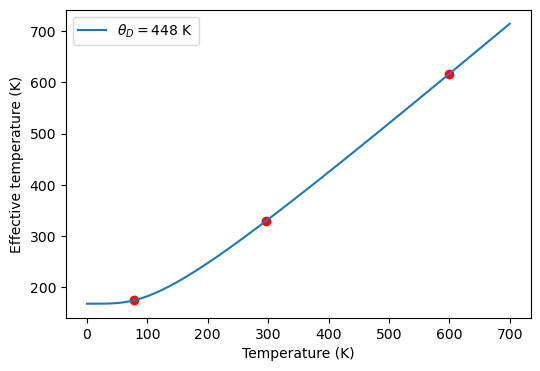

In [23]:
Tmeas=[77.7, 297, 600] # in K
Debye_temperature = 448  # in K. https://www.knowledgedoor.com/2/elements_handbook/debye_temperature.html    
Teff = {}
for t in Tmeas:
 teff=effective_temperature_debye_approximation(t, Debye_temperature)
 Teff[t] = teff

plt.figure(figsize=(6, 4))
plt.plot(np.linspace(0.1, 700, 400), effective_temperature_debye_approximation(np.linspace(0.1, 700, 400), Debye_temperature), 
label=fr"$\theta_D = {Debye_temperature}$ K")
plt.scatter(list(Teff.keys()), list(Teff.values()), color='red')
plt.xlabel("Temperature (K)")
plt.ylabel("Effective temperature (K)")
plt.legend()

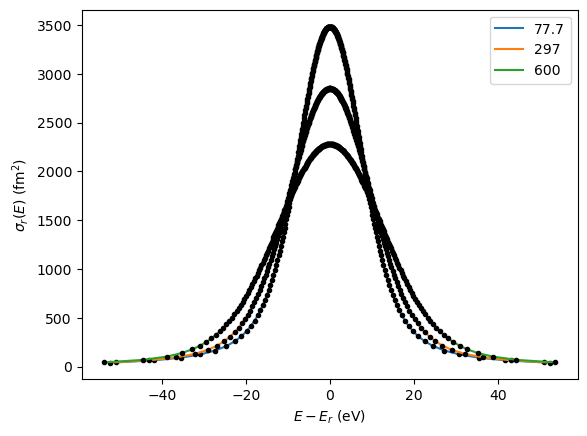

In [24]:
sigma = {
    t: Voigt(
        initial_state=li6.ground_state,
        intermediate_state=li6.excited_states['0^+_1'],
        amu=li6.amu,
        effective_temperature=teff,
    )
    for t, teff in Teff.items() 
} 
fig, ax = plt.subplots(1,1)

for t, s in sigma.items():
    sig = sigma[t]
    _energies_plot = sig.equidistant_probability_grid(0.97, 301)-sig.intermediate_state.excitation_energy
    _energies_plot_eV = _energies_plot*1e6
    _sigma_plot = sig(_energies_plot, input_is_absolute_energy=False)
    ax.set_xlabel(r"$E - E_r$ (eV)")
    ax.set_ylabel(r"$\sigma_r(E)$ (fm$^2$)")
    ax.plot(_energies_plot_eV, _sigma_plot, "-", label=str(t))
    ax.plot(_energies_plot_eV, _sigma_plot, ".", color="black")
ax.legend()

In [25]:
absorber_masses = [norm(9.000e-3, 0.005e-3), norm(8.000e-3, 0.005e-3), norm(7.000e-3, 0.005e-3)]        # define yours
scatterer_masses = [norm(5.000e-3, 0.005e-3), norm(5.500e-3, 0.005e-3), norm(6.000e-3, 0.005e-3)]          # define yours

for t, sig in sigma.items():

    for m_abs in absorber_masses:
        for m_scat in scatterer_masses:
            rho_abs_1d = np.linspace(0.,areal_density(m_abs.mean(), target_diameter.mean(), li6_enrichment.mean()))

            rho_2d, E_2d = np.meshgrid(rho_abs_1d, _energies_plot)
            phi = photon_flux_density(sig, E_2d, rho_2d)

            #fig = plt.figure(figsize=(5, 5))
            #ax = fig.add_subplot(111, projection="3d")
            #ax.set_title(f"t={t}, M_abs={m_abs.mean():.3g}, M_scat={m_scat.mean():.3g}")
            #ax.set_xlabel(r"$\rho$ (fm$^{-2}$)")
            #ax.set_ylabel(r"$E - E_r$ (eV)")
            #ax.set_zlabel(r"$\Phi_a$")
            #ax.plot_surface(rho_2d, E_2d * 1e6, phi, cmap="rainbow")
            #plt.tight_layout()
            #plt.show()

<Figure size 600x600 with 0 Axes>

In [26]:
for t, sig in sigma.items():

    for m_abs in absorber_masses:
        for m_scat in scatterer_masses:
            rho_sca_1d = np.linspace(0., areal_density(m_scat.mean(), target_diameter.mean(), li6_enrichment.mean()))

            rho_sca_2d, E_2d = np.meshgrid(rho_sca_1d, _energies_plot)
            rho_abs = areal_density(m_abs.mean(), target_diameter.mean(), li6_enrichment.mean())

            alpha = (photon_flux_density(sig, E_2d, rho_abs) * resonance_absorption_density(sig, E_2d, rho_sca_2d))
#            fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "3d"})
#            ax.set_title(f"t = {t}, M_abs = {m_abs.mean():.3g}, M_scat = {m_scat.mean():.3g}")
#            ax.set_xlabel(r"$\rho - \rho_a$ (fm$^{-2}$)")
#            ax.set_ylabel(r"$E - E_r$ (eV)")
#            ax.set_zlabel(r"$\alpha_s$")
#            ax.plot_surface(rho_sca_2d, E_2d * 1e6, alpha, cmap="rainbow")
#            plt.tight_layout()
#            #plt.show()

In [27]:
def R(Gamma, absorber_mass, scatterer_mass, diameter, enrichment, effective_temperature, energy_coverage_interval=0.999):
    sigma = Voigt(initial_state=GroundState("1^+_1", two_J=2, parity=1), intermediate_state=State("0^+_1", two_J=0, parity=1,  excitation_energy=3.56288, partial_widths={"1^+_1": Gamma}), amu=natural_elements[3].isotopes[6].amu, effective_temperature=effective_temperature,)
    
    absorber_areal_density = areal_density(absorber_mass, diameter, enrichment)
    scatterer_areal_density = areal_density(scatterer_mass, diameter, enrichment)
    energy_limits = sigma.coverage_interval(energy_coverage_interval) - sigma.intermediate_state.excitation_energy
    
    return (1.-quad(lambda energy: (photon_flux_density(sigma, energy, absorber_areal_density) *(1.-np.exp(-sigma(energy, input_is_absolute_energy=False)*scatterer_areal_density))), *energy_limits)[0] / quad( lambda energy: ((1.-np.exp(-sigma(energy, input_is_absolute_energy=False)*scatterer_areal_density))), *energy_limits)[0])

In [52]:
n_random = 100  # Number of random samples per temperature
R_exp_tolerance = 1e-4  # Absolute tolerance for inversion
update_percentage = 0.01  # Progress update interval
R_target = 0.50  # Target self-absorption correction factor at 77.7 K
Gamma_fixed = 8.17e-6
density_Li2CO3 = 2.11

In [40]:
# This cell estimates the optimal absorber and scatterer masses for the Li-6 TRSA experiment.
# Here the Teff calculated from J. Rohrer is used. Teff = 411. K is is the effective temperature that corresponds to the room temperature mesurement T = 297 K. There is a deviation of 80 K between the effective temperature calculated from the Debye approximation (Teff=330 K using \theta_D=448 K) and the effective temperature calculated from J. Rohrer.
# The optimization minimizes the difference between the calculated self-absorption R and the target value R_target = 0.50 at 77.7 K, using the fixed width Gamma_fixed.
# Converts the optimized masses to grams and computes the physical thicknesses in cm. The the self-absorption R is calculated for all measured temperatures using the Debye-approximation effective temperatures.
def objective(masses):
    m_abs, m_scat = masses
    R_val = R(Gamma=Gamma_fixed, absorber_mass=m_abs, scatterer_mass=m_scat, diameter=target_diameter.mean(), enrichment=li6_enrichment.mean(), effective_temperature=411.)
    return (R_val - R_target) ** 2

result = minimize(objective, x0=[li6_absorber_mass.mean(), li6_scatterer_mass.mean()], method="Nelder-Mead", tol=1e-8)

m_abs_opt, m_scat_opt = result.x

# Convert masses to grams
m_abs_opt_g = m_abs_opt * 1e3
m_scat_opt_g = m_scat_opt * 1e3

# Calculate thickness
diameter_cm = target_diameter.mean() * 100
radius_cm = diameter_cm / 2
area_cm2 = np.pi * radius_cm**2

thickness_abs_cm = m_abs_opt_g / (density_Li2CO3 * area_cm2)
thickness_scat_cm = m_scat_opt_g / (density_Li2CO3 * area_cm2)

# Print optimized results
print("=== Optimized Masses and Thicknesses at 77.7 K ===")
print(f"Optimized absorber mass:  {m_abs_opt_g:.4f} g")
print(f"Optimized scatterer mass: {m_scat_opt_g:.4f} g")
print(f"Absorber thickness:  {thickness_abs_cm:.4f} cm")
print(f"Scatterer thickness: {thickness_scat_cm:.4f} cm")
print(f"Particle areal density (absorber): {areal_density(m_abs_opt, target_diameter.mean(), li6_enrichment.mean())/0.01:.3e} atoms/fm^2")
print(f"Particle areal density (scatterer): {areal_density(m_scat_opt, target_diameter.mean(), li6_enrichment.mean())/0.01:.3e} atoms/fm^2")

=== Optimized Masses and Thicknesses at 77.7 K ===
Optimized absorber mass:  10.1738 g
Optimized scatterer mass: 5.0744 g
Absorber thickness:  1.5348 cm
Scatterer thickness: 0.7655 cm
Particle areal density (absorber): 5.136e-02 atoms/fm^2
Particle areal density (scatterer): 2.562e-02 atoms/fm^2


In [ ]:
# Calculate R for all temperatures using optimized masses 
R_vals = {}
for T in Tmeas:
    R_vals[T] = R(Gamma=Gamma_fixed, absorber_mass=m_abs_opt, scatterer_mass=m_scat_opt, diameter=target_diameter.mean(), enrichment=li6_enrichment.mean(), effective_temperature=Teff[T])

In [98]:
# Using the known measured self-absorption at room temperature 
#R_mid_measured = R_exp.mean() if "R_exp" in globals() else R_vals[297]
#print(f"\nReference self-absorption at 297 K: {R_mid_measured:.6f}")
## Step 1: infer Gamma from the known middle-temperature measurement
#def objective_gamma(gamma):
#    gamma = float(np.atleast_1d(gamma)[0])
#    if gamma <= 0:
#        return np.inf
#    R_mid = R(Gamma=gamma, absorber_mass=li6_absorber_mass.mean(), scatterer_mass=li6_scatterer_mass.mean(), diameter=target_diameter.mean(), enrichment=li6_enrichment.mean(), effective_temperature=float(Teff[297]))
#    return (R_mid - R_mid_measured) ** 2
#
#gamma_fit = minimize(objective_gamma, x0=[Gamma_fixed], method="Nelder-Mead", tol=1e-10).x[0]

In [99]:
Gamma_fixed = ufloat(8.14, 0.14) * 1e-6
def objective_lowT(masses):
    m_abs_trial, m_scat_trial = masses
    if m_abs_trial <= 0 or m_scat_trial <= 0:
        return np.inf
    R_low = R(Gamma=Gamma_fixed.n,absorber_mass=m_abs_trial,scatterer_mass=m_scat_trial,diameter=target_diameter.mean(),enrichment=li6_enrichment.mean(),effective_temperature=float(Teff[77.7]))
    return (R_low - R_target) ** 2

result_lowT = minimize(objective_lowT, x0=[li6_absorber_mass.mean(), li6_scatterer_mass.mean()], method="Nelder-Mead", tol=1e-10)

m_abs_lowT, m_scat_lowT = result_lowT.x
thickness_abs_lowT_cm = (m_abs_lowT * 1e3) / (density_Li2CO3 * area_cm2)
thickness_scat_lowT_cm = (m_scat_lowT * 1e3) / (density_Li2CO3 * area_cm2)

# Calculates the self-absorption using the effective temperature from the Debye approximation and the optimized masses at low temperature for all measured temperatures (for which R=0.50)
R_consistent = {T: R(Gamma=Gamma_fixed.n, absorber_mass=m_abs_lowT, scatterer_mass=m_scat_lowT, diameter=target_diameter.mean(), enrichment=li6_enrichment.mean(), effective_temperature=float(Teff[T])) for T in Tmeas}

# Propagate Gamma uncertainty into R at each measurement temperature.
gamma_samples_summary = np.random.normal(Gamma_fixed.n, Gamma_fixed.s, n_random)
R_unc = {}
for T in Tmeas:
    R_samples_T = [
        R(Gamma=float(g),absorber_mass=m_abs_lowT,scatterer_mass=m_scat_lowT,diameter=target_diameter.mean(),enrichment=li6_enrichment.mean(),effective_temperature=float(Teff[T])) for g in gamma_samples_summary]

    R_unc[T] = np.std(R_samples_T)

In [103]:
print("Estimation of absorbing and scatetring targets masses and thicknesses for the TRSA experiment:\n------------------------------------------------------")
print(f"Fitted Gamma from RSA measurement: {Gamma_fixed*1e6:.4f} eV")
print("Masses:")
print(f"Optimized absorber mass: {m_abs_lowT*1e3:.4f} g")
print(f"Optimized scatterer mass: {m_scat_lowT*1e3:.4f} g")
print("Thicknesses:")
print(f"Absorber thickness: {thickness_abs_lowT_cm:.4f} cm ({thickness_abs_lowT_cm*10:.3f} mm)")
print(f"Scatterer thickness: {thickness_scat_lowT_cm:.4f} cm ({thickness_scat_lowT_cm*10:.3f} mm)")
print("\nPredicted self-absorption values for the new targets:")

for T in Tmeas:
    print(f"T = {T:6.2f} K : R = {R_consistent[T]:.6f} ± {R_unc[T]:.6f}")

Estimation of absorbing and scatetring targets masses and thicknesses for the TRSA experiment:
------------------------------------------------------
Fitted Gamma from RSA measurement: 8.1400+/-0.1400 eV
Masses:
Optimized absorber mass: 8.7275 g
Optimized scatterer mass: 5.6045 g
Thicknesses:
Absorber thickness: 1.3166 cm (13.166 mm)
Scatterer thickness: 0.8455 cm (8.455 mm)

Predicted self-absorption values for the new targets:
T =  77.70 K : R = 0.500000 ± 0.001540
T = 297.00 K : R = 0.467206 ± 0.002321
T = 600.00 K : R = 0.422692 ± 0.002976
